# Pooling Strategy Comparison Results

This notebook visualizes the results from the pooling strategy comparison experiment.

**Pooling strategies tested:**
- **Average Pooling**: Global average across all spatial dimensions (384-dim)
- **Multiscale Pooling**: Concatenation at 1×1×1, 2×2×2, 4×4×4 scales (1920-dim)
- **Percentile Pooling**: 10th, 25th, 50th, 75th, 90th percentiles (1920-dim)

---

## 🔄 Quick Start: Switch Between Pooling Strategies

To view results for a specific pooling strategy:
1. Find the **"Filter by Pooling Strategy"** cell below
2. Change `selected_strategy = None` to:
   - `selected_strategy = 'avg'` for Average Pooling only
   - `selected_strategy = 'multiscale'` for Multiscale Pooling only
   - `selected_strategy = 'percentile'` for Percentile Pooling only
3. Re-run all cells (Ctrl+Shift+Enter or "Run All")

Leave as `None` to compare all strategies side-by-side.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Results

In [2]:
# Load the pooling comparison results
results_path = Path('../../results/pooling_comparison/pooling_comparison_latest.csv')

df = pd.read_csv(results_path)
print(f"Loaded {len(df)} results")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDatasets: {df['dataset'].unique()}")
print(f"Pooling strategies: {df['pooling_strategy'].unique()}")

df.head()

Loaded 18 results

Columns: ['dataset', 'pooling_strategy', 'accuracy', 'accuracy_std', 'macro_f1', 'macro_f1_std', 'roc_auc', 'roc_auc_std', 'n_samples', 'n_features_original', 'n_features_pca']

Datasets: ['crlm' 'desmoid' 'gist' 'lipo' 'liver' 'melanoma']
Pooling strategies: ['avg' 'multiscale' 'percentile']


,dataset,pooling_strategy,accuracy,accuracy_std,macro_f1,macro_f1_std,roc_auc,roc_auc_std,n_samples,n_features_original,n_features_pca
0,crlm,avg,0.375833,0.104762,0.348715,0.118703,0.405804,0.122361,77,384,60
1,desmoid,avg,0.655732,0.057150,0.537177,0.085056,0.670033,0.067151,203,384,161
2,gist,avg,0.556735,0.046866,0.555351,0.046324,0.594687,0.066016,246,384,195
3,lipo,avg,0.591304,0.052174,0.586498,0.051215,0.603788,0.078496,115,384,91
4,liver,avg,0.580512,0.063727,0.569921,0.053921,0.576962,0.060197,186,384,147


## Filter by Pooling Strategy (Optional)

Set `selected_strategy` to filter results for a specific pooling strategy, or leave as `None` to show all.

In [ ]:
# ========================================
# CONFIGURATION: Select Pooling Strategy
# ========================================
# Options: None (all), 'avg', 'multiscale', 'percentile'

selected_strategy = None  # Change to 'avg', 'multiscale', or 'percentile' to filter

# Apply filter if specified
if selected_strategy is not None:
    print(f"📊 Filtering to show only: {selected_strategy}")
    df_filtered = df[df['pooling_strategy'] == selected_strategy].copy()
    if len(df_filtered) == 0:
        print(f"⚠️  No results found for '{selected_strategy}'")
        df_filtered = df.copy()
else:
    print("📊 Showing all pooling strategies")
    df_filtered = df.copy()

print(f"Results to visualize: {len(df_filtered)} rows")
print(f"Strategies included: {df_filtered['pooling_strategy'].unique().tolist()}")

## Check for Errors

*(Uses filtered data if strategy selected above)*

In [ ]:
# Check if there are any errors
if 'error' in df_filtered.columns:
    errors = df_filtered[df_filtered['error'].notna()]
    if len(errors) > 0:
        print(f"⚠️  Found {len(errors)} errors:")
        print(errors[['dataset', 'pooling_strategy', 'error']].to_string())
    else:
        print("✅ No errors found")
        
    # Filter to successful runs only
    df_filtered = df_filtered[df_filtered['error'].isna()].copy()
    print(f"\n✓ {len(df_filtered)} successful runs")

## Summary Statistics

In [ ]:
# Display summary statistics by pooling strategy
if len(df_filtered) > 0 and 'accuracy' in df_filtered.columns:
    summary = df_filtered.groupby('pooling_strategy')[['accuracy', 'macro_f1', 'roc_auc']].agg(['mean', 'std', 'min', 'max'])
    print("Summary by Pooling Strategy:")
    print(summary.round(4))
else:
    print("No successful results with metrics to summarize")

Summary by Pooling Strategy:
                 accuracy                         macro_f1                  \
                     mean     std     min     max     mean     std     min   
pooling_strategy                                                             
avg                0.5616  0.0969  0.3758  0.6557   0.5330  0.0930  0.3487   
multiscale         0.6044  0.0705  0.5248  0.7141   0.5818  0.0487  0.5186   
percentile         0.6033  0.0607  0.4942  0.6700   0.5780  0.0552  0.4797   

                         roc_auc                          
                     max    mean     std     min     max  
pooling_strategy                                          
avg               0.6001  0.5844  0.0946  0.4058  0.6700  
multiscale        0.6392  0.6238  0.0532  0.5580  0.6927  
percentile        0.6408  0.6374  0.0797  0.4924  0.7103  


## Visualization 1: Accuracy Comparison

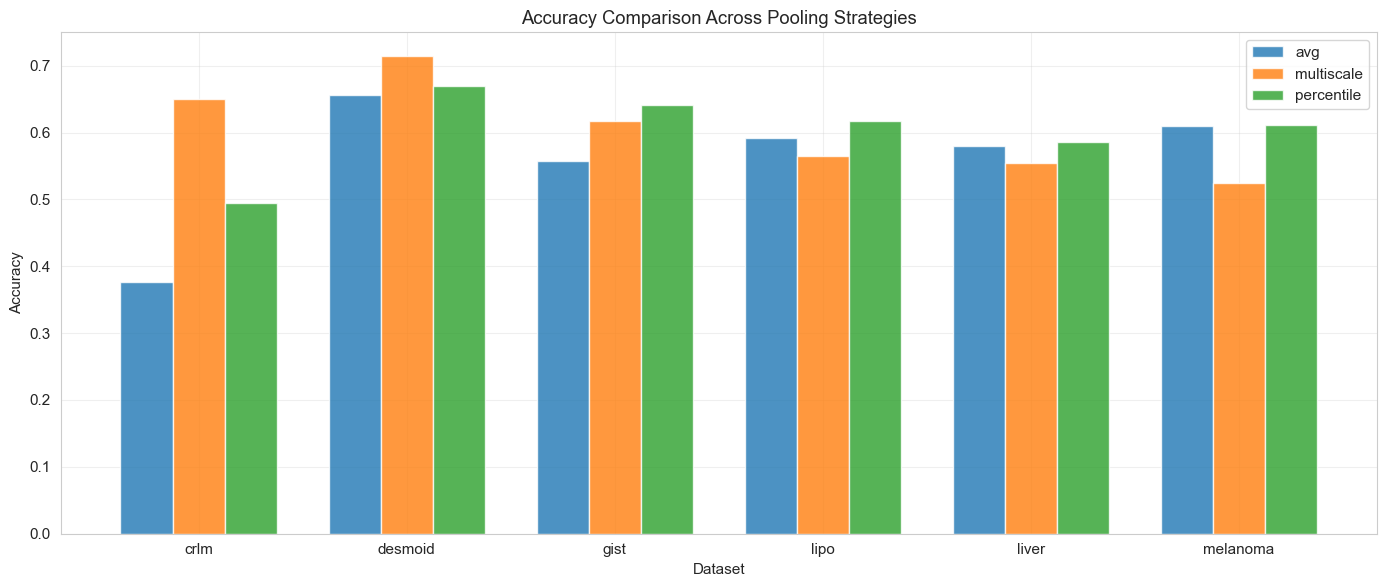

In [ ]:
if len(df_filtered) > 0 and 'accuracy' in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Bar plot
    x = np.arange(len(df_filtered['dataset'].unique()))
    width = 0.25 if len(df_filtered['pooling_strategy'].unique()) == 3 else 0.4
    strategies = df_filtered['pooling_strategy'].unique()
    
    for i, strategy in enumerate(strategies):
        data = df_filtered[df_filtered['pooling_strategy'] == strategy]
        accuracies = [data[data['dataset'] == ds]['accuracy'].values[0] if len(data[data['dataset'] == ds]) > 0 else 0 
                     for ds in df_filtered['dataset'].unique()]
        ax.bar(x + i*width, accuracies, width, label=strategy, alpha=0.8)
    
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Comparison Across Pooling Strategies')
    ax.set_xticks(x + width * (len(strategies) - 1) / 2)
    ax.set_xticklabels(df_filtered['dataset'].unique())
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot")

## Visualization 2: ROC AUC Comparison

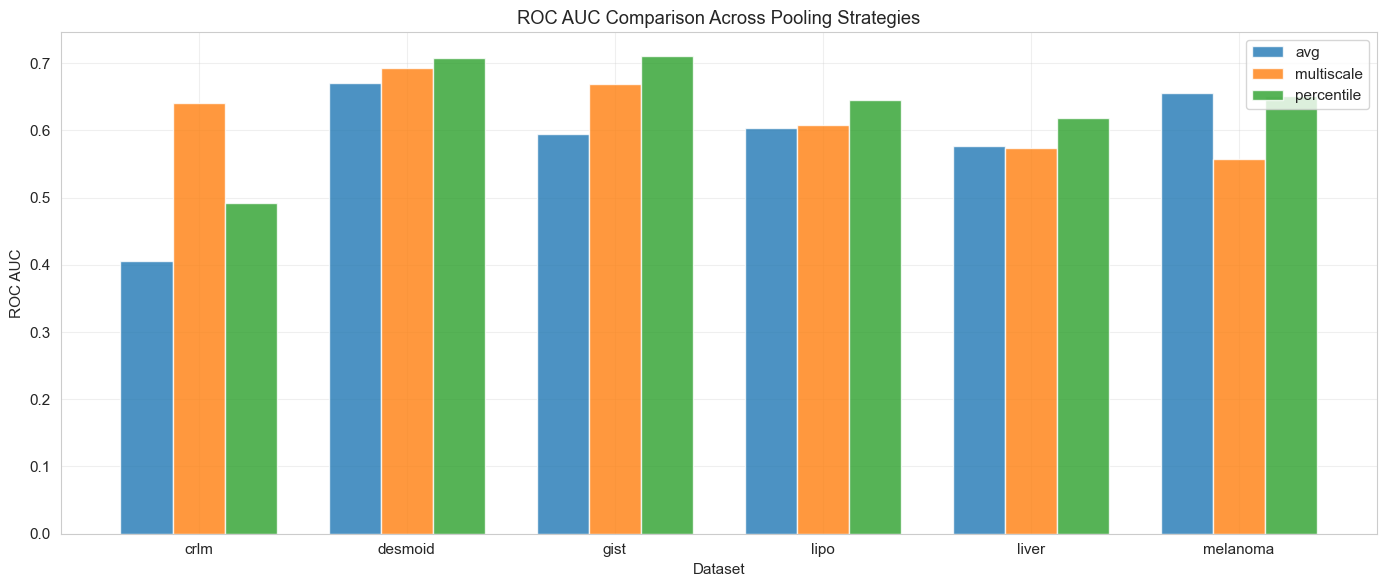

In [ ]:
if len(df_filtered) > 0 and 'roc_auc' in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(df_filtered['dataset'].unique()))
    width = 0.25 if len(df_filtered['pooling_strategy'].unique()) == 3 else 0.4
    strategies = df_filtered['pooling_strategy'].unique()
    
    for i, strategy in enumerate(strategies):
        data = df_filtered[df_filtered['pooling_strategy'] == strategy]
        aucs = [data[data['dataset'] == ds]['roc_auc'].values[0] if len(data[data['dataset'] == ds]) > 0 else 0 
               for ds in df_filtered['dataset'].unique()]
        ax.bar(x + i*width, aucs, width, label=strategy, alpha=0.8)
    
    ax.set_xlabel('Dataset')
    ax.set_ylabel('ROC AUC')
    ax.set_title('ROC AUC Comparison Across Pooling Strategies')
    ax.set_xticks(x + width * (len(strategies) - 1) / 2)
    ax.set_xticklabels(df_filtered['dataset'].unique())
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No ROC AUC data to plot")

## Visualization 3: Macro F1 Score Comparison

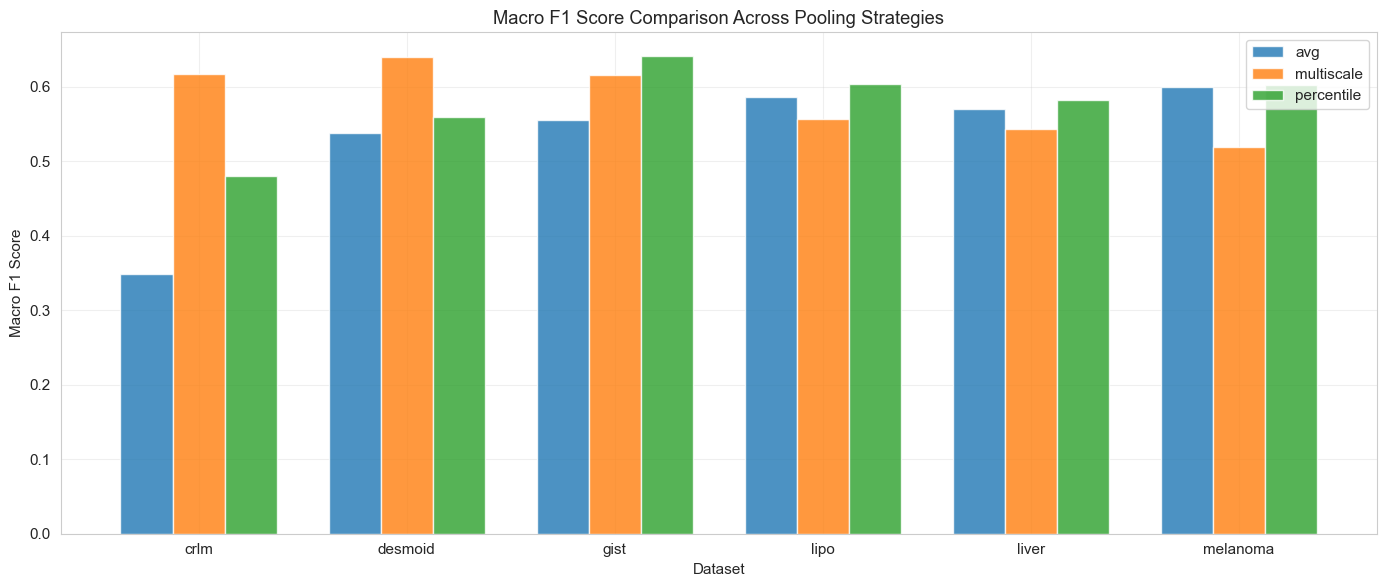

In [ ]:
if len(df_filtered) > 0 and 'macro_f1' in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(df_filtered['dataset'].unique()))
    width = 0.25 if len(df_filtered['pooling_strategy'].unique()) == 3 else 0.4
    strategies = df_filtered['pooling_strategy'].unique()
    
    for i, strategy in enumerate(strategies):
        data = df_filtered[df_filtered['pooling_strategy'] == strategy]
        f1s = [data[data['dataset'] == ds]['macro_f1'].values[0] if len(data[data['dataset'] == ds]) > 0 else 0 
              for ds in df_filtered['dataset'].unique()]
        ax.bar(x + i*width, f1s, width, label=strategy, alpha=0.8)
    
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Macro F1 Score')
    ax.set_title('Macro F1 Score Comparison Across Pooling Strategies')
    ax.set_xticks(x + width * (len(strategies) - 1) / 2)
    ax.set_xticklabels(df_filtered['dataset'].unique())
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No Macro F1 data to plot")

## Visualization 4: Heatmap of Performance

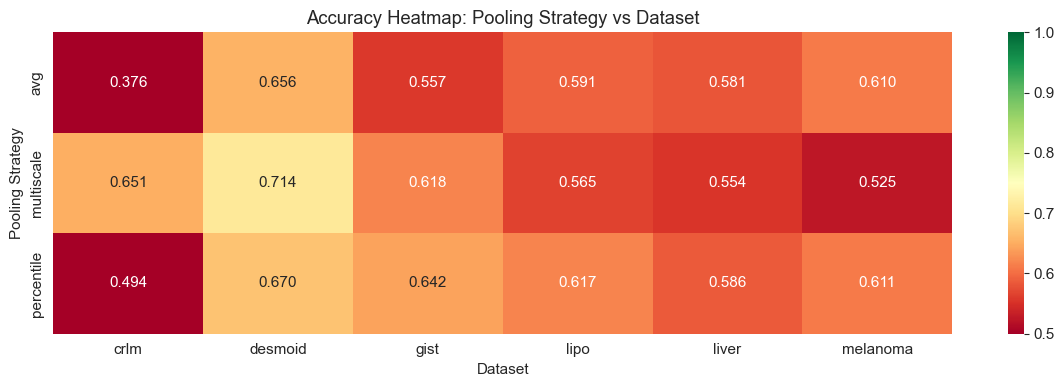

In [ ]:
if len(df_filtered) > 0 and 'accuracy' in df_filtered.columns:
    # Create pivot table for heatmap
    pivot_acc = df_filtered.pivot(index='pooling_strategy', columns='dataset', values='accuracy')
    
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title('Accuracy Heatmap: Pooling Strategy vs Dataset')
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Pooling Strategy')
    plt.tight_layout()
    plt.show()
else:
    print("No data for heatmap")

## Visualization 5: Average Performance by Strategy

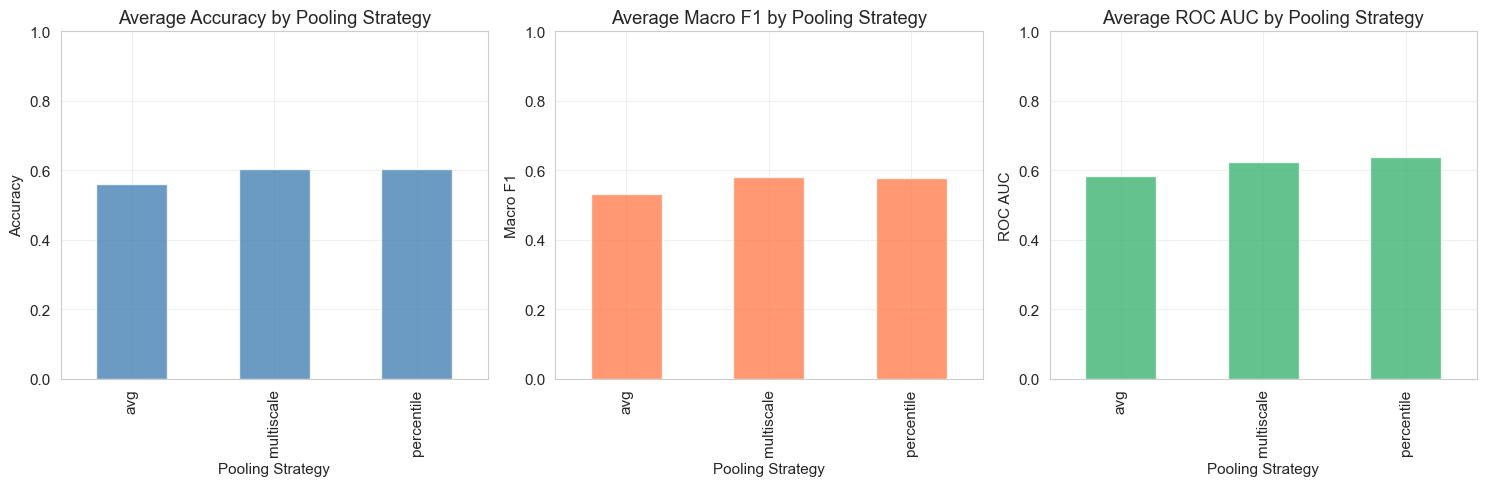


Average Metrics:
                  accuracy  macro_f1  roc_auc
pooling_strategy                             
avg                 0.5616    0.5330   0.5844
multiscale          0.6044    0.5818   0.6238
percentile          0.6033    0.5780   0.6374


In [ ]:
if len(df_filtered) > 0 and 'accuracy' in df_filtered.columns:
    # Calculate average metrics per strategy
    avg_metrics = df_filtered.groupby('pooling_strategy')[['accuracy', 'macro_f1', 'roc_auc']].mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Accuracy
    avg_metrics['accuracy'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
    axes[0].set_title('Average Accuracy by Pooling Strategy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Pooling Strategy')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])
    
    # Macro F1
    avg_metrics['macro_f1'].plot(kind='bar', ax=axes[1], color='coral', alpha=0.8)
    axes[1].set_title('Average Macro F1 by Pooling Strategy')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_xlabel('Pooling Strategy')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    # ROC AUC
    avg_metrics['roc_auc'].plot(kind='bar', ax=axes[2], color='mediumseagreen', alpha=0.8)
    axes[2].set_title('Average ROC AUC by Pooling Strategy')
    axes[2].set_ylabel('ROC AUC')
    axes[2].set_xlabel('Pooling Strategy')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    print("\nAverage Metrics:")
    print(avg_metrics.round(4))
else:
    print("No data to plot")

## Winner Analysis

In [ ]:
if len(df_filtered) > 0 and 'accuracy' in df_filtered.columns:
    print("🏆 Best Pooling Strategy per Dataset:\n")
    
    for dataset in df_filtered['dataset'].unique():
        dataset_df = df_filtered[df_filtered['dataset'] == dataset]
        
        best_acc = dataset_df.loc[dataset_df['accuracy'].idxmax()]
        best_auc = dataset_df.loc[dataset_df['roc_auc'].idxmax()]
        
        print(f"{dataset.upper()}:")
        print(f"  Best Accuracy: {best_acc['pooling_strategy']} ({best_acc['accuracy']:.4f})")
        print(f"  Best ROC AUC:  {best_auc['pooling_strategy']} ({best_auc['roc_auc']:.4f})")
        print()
    
    # Overall winner (only if comparing multiple strategies)
    if len(df_filtered['pooling_strategy'].unique()) > 1:
        avg_metrics = df_filtered.groupby('pooling_strategy')[['accuracy', 'roc_auc']].mean()
        overall_winner = avg_metrics['roc_auc'].idxmax()
        
        print(f"\n🥇 OVERALL WINNER (by average ROC AUC): {overall_winner}")
        print(f"   Average ROC AUC: {avg_metrics.loc[overall_winner, 'roc_auc']:.4f}")
        print(f"   Average Accuracy: {avg_metrics.loc[overall_winner, 'accuracy']:.4f}")
else:
    print("No data for winner analysis")

🏆 Best Pooling Strategy per Dataset:

CRLM:
  Best Accuracy: multiscale (0.6508)
  Best ROC AUC:  multiscale (0.6406)

DESMOID:
  Best Accuracy: multiscale (0.7141)
  Best ROC AUC:  percentile (0.7070)

GIST:
  Best Accuracy: percentile (0.6419)
  Best ROC AUC:  percentile (0.7103)

LIPO:
  Best Accuracy: percentile (0.6174)
  Best ROC AUC:  percentile (0.6455)

LIVER:
  Best Accuracy: percentile (0.5856)
  Best ROC AUC:  percentile (0.6188)

MELANOMA:
  Best Accuracy: percentile (0.6110)
  Best ROC AUC:  avg (0.6551)


🥇 OVERALL WINNER (by average ROC AUC): percentile
   Average ROC AUC: 0.6374
   Average Accuracy: 0.6033


## Export Summary

In [ ]:
if len(df_filtered) > 0:
    # Save summary to file
    summary_path = Path('../../results/pooling_comparison/pooling_summary_statistics.csv')
    summary = df_filtered.groupby('pooling_strategy')[['accuracy', 'macro_f1', 'roc_auc']].agg(['mean', 'std'])
    summary.to_csv(summary_path)
    print(f"✅ Summary statistics saved to: {summary_path}")

✅ Summary statistics saved to: ..\..\results\pooling_comparison\pooling_summary_statistics.csv
